# Yuva Internship - Week 2: Exploratory Data Analysis & Visualization
## Project: Netflix Movies and TV Shows Dataset
**Student Name:** Vikhyath Bharadwaj K S  
**Dataset:** Netflix Movies and TV Shows by Shivam Bansal (Kaggle)  
**Deliverable:** Week 2 Fully Executed Jupyter Notebook  
---

### 1. Project Introduction
Exploratory Data Analysis (EDA) is a critical stage in the data science pipeline that involves investigating dataset structures, detecting patterns, uncovering anomalies, and summarizing key statistical characteristics through visual and quantitative methods. Following the completion of Week 1 (Data Acquisition, Cleaning, and Preprocessing), this notebook performs an in-depth exploratory analysis on the curated Netflix Movies and TV Shows dataset. The goal is to extract meaningful content insights, geographic production dynamics, temporal evolution, and rating characteristics.

### 2. Objectives
1. Perform comprehensive univariate and bivariate analysis on Netflix content.
2. Quantify content breakdown between Movies and TV Shows.
3. Track release year trends and Netflix catalog expansion seasonality.
4. Analyze international content distribution accounting for multi-country co-productions.
5. Evaluate listed genre distributions and age target rating categories.
6. Conduct statistical distribution analysis for movie durations and TV show season counts.
7. Perform statistical hypothesis testing (Chi-Square Test of Independence & ANOVA / Kruskal-Wallis).
8. Generate 12 high-resolution publication-quality data visualizations.

### 3. Dataset Source and Description
- **Source:** Kaggle - Netflix Movies and TV Shows (Shivam Bansal)
- **Original Size:** 7,787 rows × 12 columns
- **Cleaned/Processed Size:** 7,787 rows × 28 columns
- **Key Fields:** `show_id`, `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in`, `description`, `content_age`, `primary_genre`, `target_audience`.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# Visual style setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


### 5. Dataset Loading
We load both the cleaned dataset (`netflix_cleaned.csv`) and the feature-engineered processed dataset (`netflix_processed.csv`).

In [2]:
CLEANED_PATH = '../dataset/processed/netflix_cleaned.csv'
PROCESSED_PATH = '../dataset/processed/netflix_processed.csv'

df_clean = pd.read_csv(CLEANED_PATH)
df_proc = pd.read_csv(PROCESSED_PATH)

# Convert date fields
df_proc['date_added_dt'] = pd.to_datetime(df_proc['date_added'], errors='coerce')

print(f"Cleaned Dataset Shape: {df_clean.shape}")
print(f"Processed Dataset Shape: {df_proc.shape}")
df_proc.head(3)

Cleaned Dataset Shape: (7787, 12)
Processed Dataset Shape: (7787, 28)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,content_age,duration_int,duration_unit,primary_genre,genre_count,primary_country,country_count,cast_count,target_audience,is_movie
0,s1,TV Show,3%,Unknown Director,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,...,0,4,Seasons,International TV Shows,3,Brazil,1,11,Adults,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,...,0,93,min,Dramas,2,Mexico,1,6,Adults,1
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,...,7,78,min,Horror Movies,2,Singapore,1,9,Adults,1


### 6. Initial Inspection
Inspecting column data types, non-null value counts, and unique value counts across key variables.

In [3]:
# Dataset Summary
inspection_df = pd.DataFrame({
    'Data Type': df_proc.dtypes,
    'Non-Null Count': df_proc.notnull().sum(),
    'Null Count': df_proc.isnull().sum(),
    'Unique Values': df_proc.nunique()
})
print("--- DATASET COLUMN INSPECTION ---")
display(inspection_df)

--- DATASET COLUMN INSPECTION ---


,Data Type,Non-Null Count,Null Count,Unique Values
show_id,object,7787,0,7787
type,object,7787,0,2
title,object,7787,0,7786
director,object,7787,0,4050
cast,object,7787,0,6832
country,object,7787,0,682
date_added,object,7787,0,1520
release_year,int64,7787,0,73
rating,object,7787,0,14
duration,object,7787,0,216


### 7. Descriptive Statistics
Calculating central tendency, dispersion, skewness, and kurtosis for numeric variables (`release_year`, `duration_int`, `content_age`, `cast_count`, `country_count`).

In [4]:
numeric_cols = ['release_year', 'duration_int', 'content_age', 'cast_count', 'country_count', 'genre_count']
desc_stats = df_proc[numeric_cols].describe().T
desc_stats['skewness'] = df_proc[numeric_cols].skew()
desc_stats['kurtosis'] = df_proc[numeric_cols].kurtosis()
print("--- NUMERICAL DESCRIPTIVE STATISTICS ---")
display(desc_stats.round(2))

--- NUMERICAL DESCRIPTIVE STATISTICS ---


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
release_year,7787.0,2013.93,8.76,1925.0,2013.0,2017.0,2018.0,2021.0,-3.62,17.57
duration_int,7787.0,69.12,50.95,1.0,2.0,88.0,106.0,312.0,-0.16,-1.11
content_age,7787.0,4.55,8.73,0.0,0.0,1.0,5.0,93.0,3.68,17.63
cast_count,7787.0,7.19,4.86,0.0,4.0,8.0,10.0,50.0,1.17,6.74
country_count,7787.0,1.16,0.73,0.0,1.0,1.0,1.0,12.0,3.26,20.52
genre_count,7787.0,2.19,0.79,1.0,2.0,2.0,3.0,3.0,-0.35,-1.30


### 8. Content Type Analysis
Analyzing the proportion of Movies versus TV Shows in the Netflix catalog.

--- CONTENT TYPE BREAKDOWN ---


,Count,Percentage (%)
type,,
Movie,5377,69.05
TV Show,2410,30.95


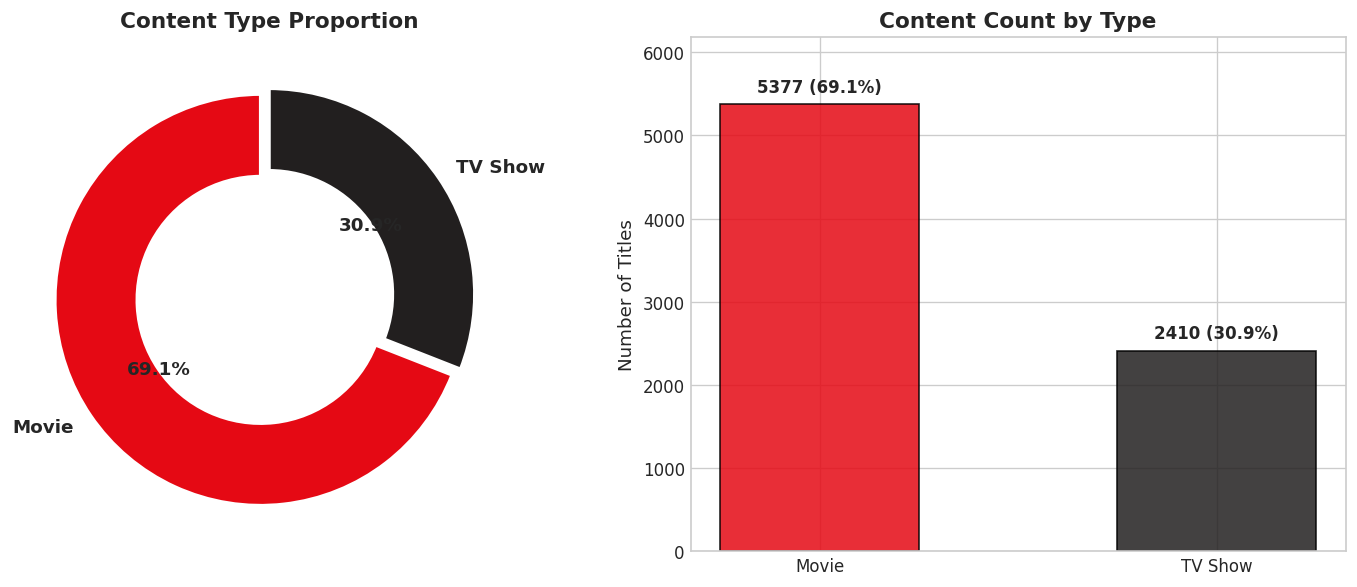

In [5]:
type_summary = pd.DataFrame({
    'Count': df_proc['type'].value_counts(),
    'Percentage (%)': (df_proc['type'].value_counts(normalize=True) * 100).round(2)
})
print("--- CONTENT TYPE BREAKDOWN ---")
display(type_summary)

# Plotting Chart 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#E50914', '#221F1F']
type_counts = df_proc['type'].value_counts()

ax1.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0),
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), textprops=dict(fontsize=11, fontweight='bold'))
ax1.set_title('Content Type Proportion', fontsize=13, fontweight='bold')

bars = ax2.bar(type_counts.index, type_counts.values, color=colors, width=0.5, edgecolor='black', alpha=0.85)
ax2.set_ylabel('Number of Titles', fontsize=11)
ax2.set_title('Content Count by Type', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(type_counts.values) * 1.15)
for bar in bars:
    h = bar.get_height()
    pct_val = (h / len(df_proc)) * 100
    label_str = str(h) + f" ({pct_val:.1f}%)"
    ax2.annotate(label_str, xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 9. Release Year Analysis
Tracking release year distribution from 1925 to 2021 and highlighting peak production periods.

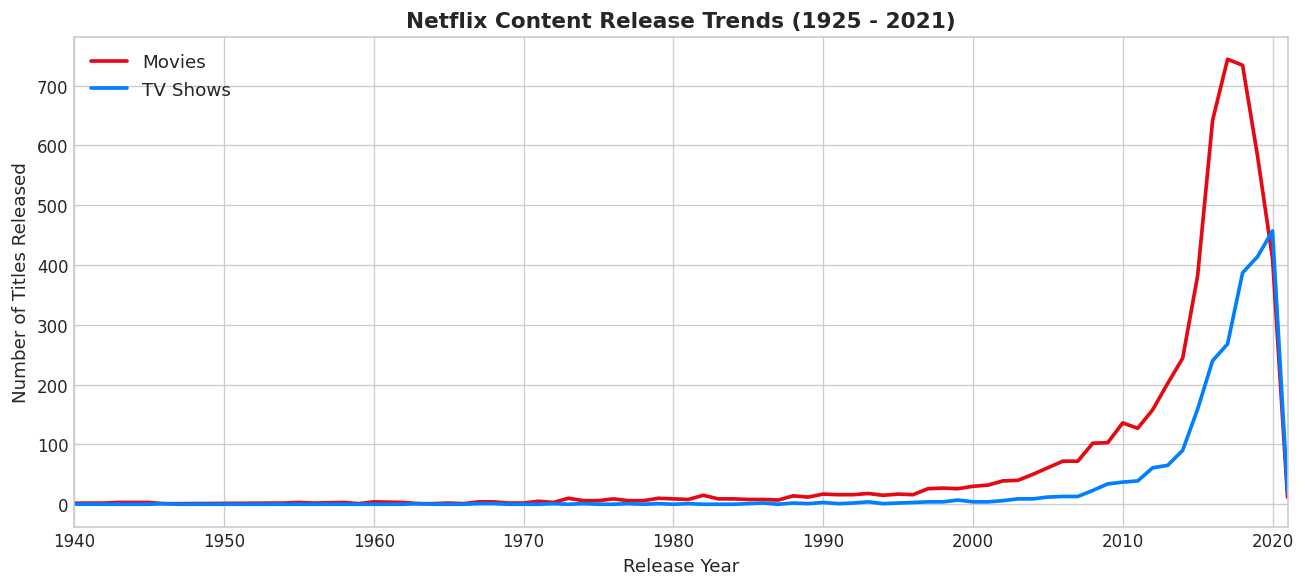

In [6]:
year_type = df_proc.groupby(['release_year', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(year_type.index, year_type['Movie'], label='Movies', color='#E50914', linewidth=2.2)
ax.plot(year_type.index, year_type['TV Show'], label='TV Shows', color='#0080FF', linewidth=2.2)
ax.set_title('Netflix Content Release Trends (1925 - 2021)', fontsize=13, fontweight='bold')
ax.set_xlabel('Release Year', fontsize=11)
ax.set_ylabel('Number of Titles Released', fontsize=11)
ax.set_xlim(1940, 2021)
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

### 10. Country Analysis
Handling multi-country co-productions by exploding comma-separated values to evaluate true geographic production shares.

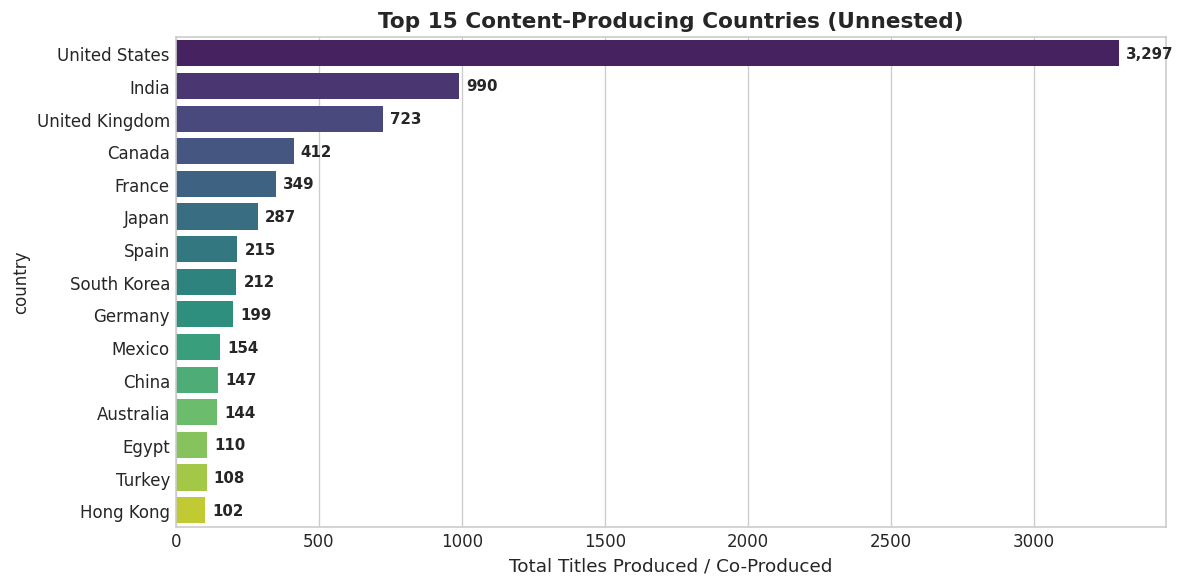

In [7]:
country_series = df_proc[df_proc['country'] != 'Unknown Country']['country'].dropna()
exploded_countries = country_series.apply(lambda x: [c.strip() for c in str(x).split(',')]).explode()
top_15_countries = exploded_countries.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_15_countries.values, y=top_15_countries.index, hue=top_15_countries.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Top 15 Content-Producing Countries (Unnested)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Titles Produced / Co-Produced', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width() + 25, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### 11. Genre Analysis
Evaluating unnested genre occurrences across the catalog.

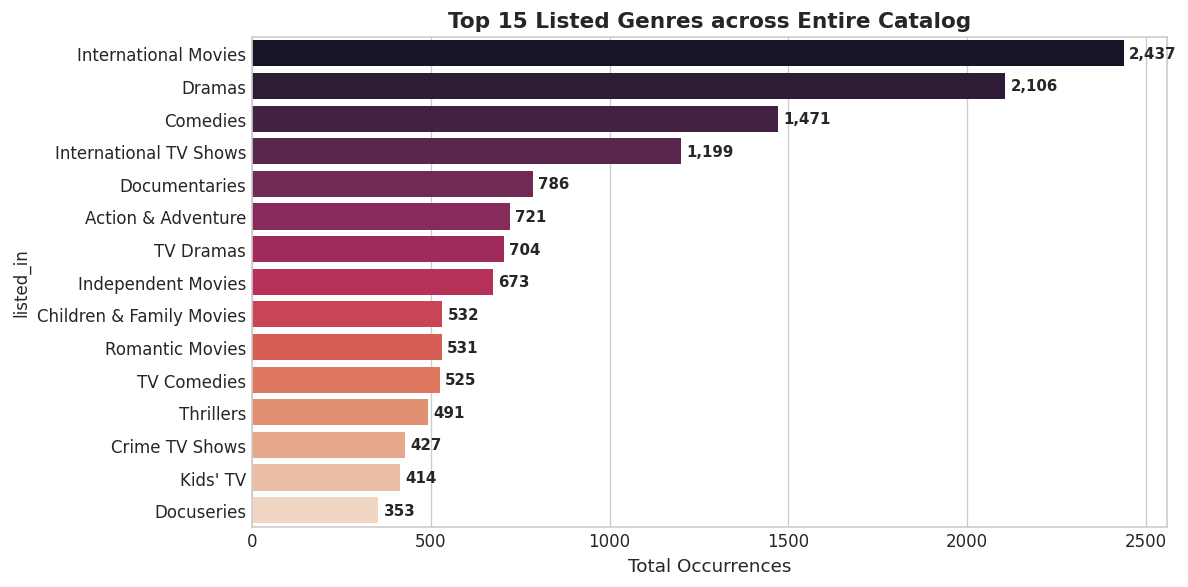

In [8]:
genre_series = df_proc['listed_in'].apply(lambda x: [g.strip() for g in str(x).split(',')]).explode()
top_15_genres = genre_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_15_genres.values, y=top_15_genres.index, hue=top_15_genres.index, palette='rocket', legend=False, ax=ax)
ax.set_title('Top 15 Listed Genres across Entire Catalog', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Occurrences', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width() + 15, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### 12. Rating Analysis
Examining content rating distributions across Movies and TV Shows.

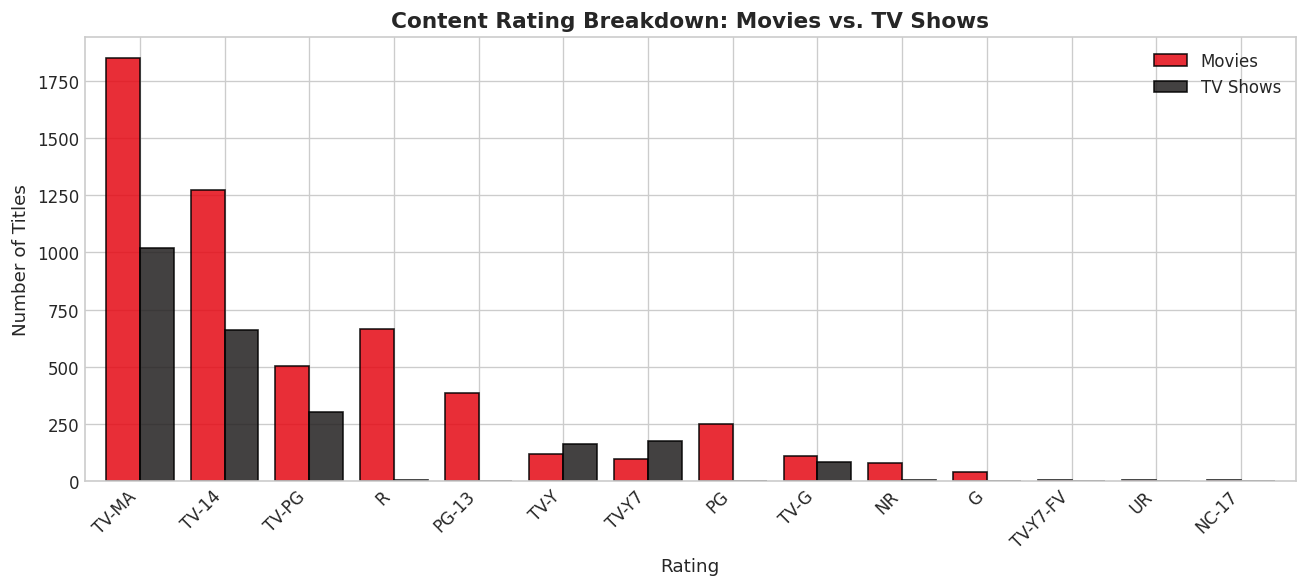

In [9]:
rating_type = pd.crosstab(df_proc['rating'], df_proc['type'])
rating_order = df_proc['rating'].value_counts().index
rating_type = rating_type.loc[rating_order]

fig, ax = plt.subplots(figsize=(11, 5))
rating_type.plot(kind='bar', color=['#E50914', '#221F1F'], ax=ax, width=0.8, edgecolor='black', alpha=0.85)
ax.set_title('Content Rating Breakdown: Movies vs. TV Shows', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating', fontsize=11)
ax.set_ylabel('Number of Titles', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(['Movies', 'TV Shows'], fontsize=10)
plt.tight_layout()
plt.show()

### 13. Duration Analysis
Analyzing Movie durations (in minutes) and TV Show season counts.

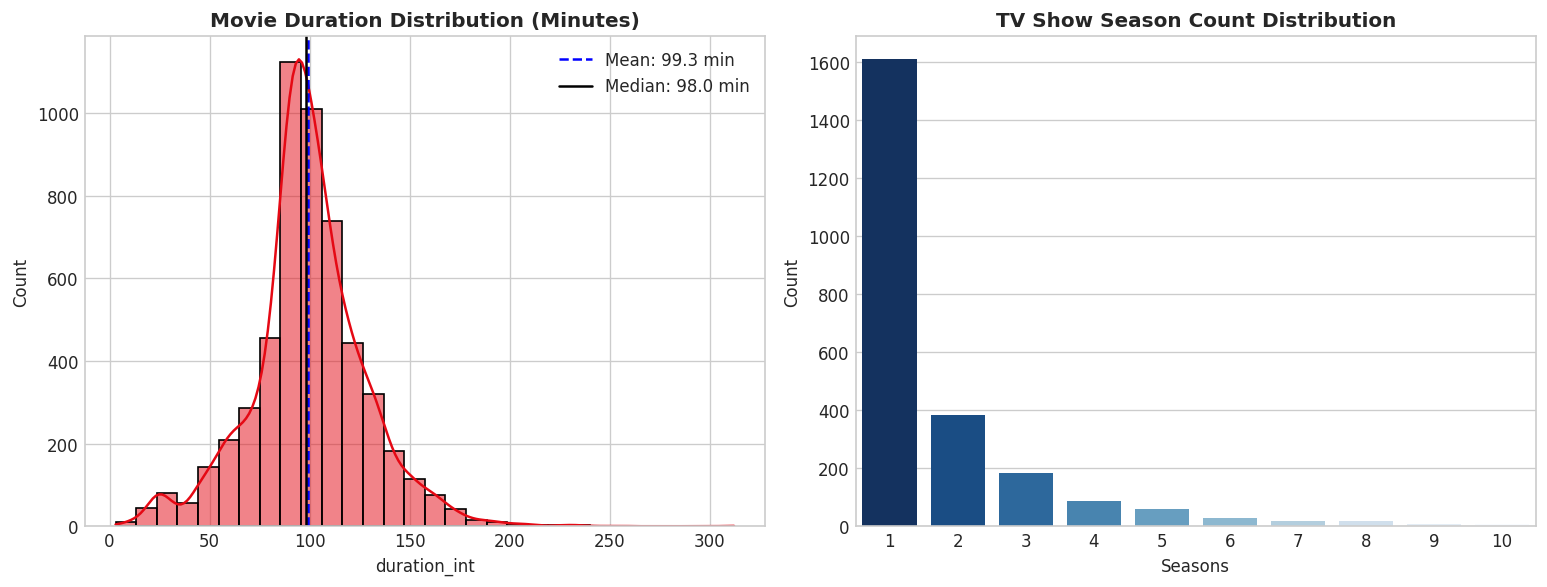

In [10]:
movie_durations = df_proc[df_proc['type'] == 'Movie']['duration_int'].dropna()
tv_seasons = df_proc[df_proc['type'] == 'TV Show']['duration_int'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Movie duration histogram
sns.histplot(movie_durations, bins=30, kde=True, color='#E50914', ax=ax1)
ax1.axvline(movie_durations.mean(), color='blue', linestyle='--', label=f'Mean: {movie_durations.mean():.1f} min')
ax1.axvline(movie_durations.median(), color='black', linestyle='-', label=f'Median: {movie_durations.median():.1f} min')
ax1.set_title('Movie Duration Distribution (Minutes)', fontsize=12, fontweight='bold')
ax1.legend()

# TV Seasons bar chart
season_counts = tv_seasons.value_counts().sort_index().head(10).reset_index()
season_counts.columns = ['Seasons', 'Count']
sns.barplot(x='Seasons', y='Count', data=season_counts, hue='Seasons', palette='Blues_r', legend=False, ax=ax2)
ax2.set_title('TV Show Season Count Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 14. Date Added Analysis
Analyzing Netflix content additions by month and calculating content age lag.

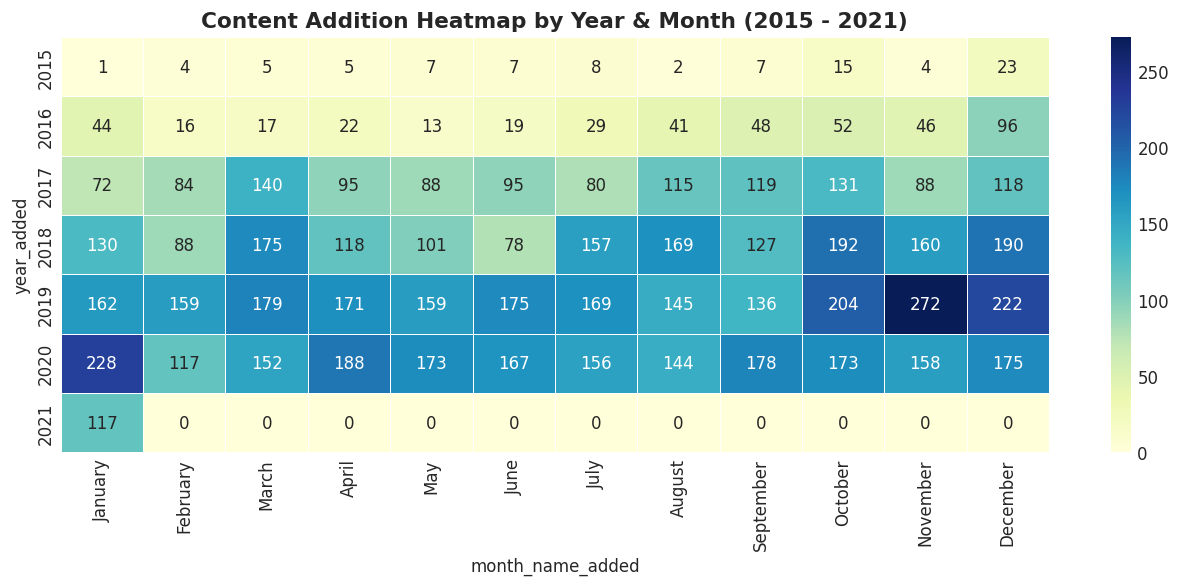

In [11]:
df_valid_date = df_proc.dropna(subset=['date_added_dt']).copy()
recent_years = df_valid_date[df_valid_date['year_added'] >= 2015]
monthly_matrix = pd.crosstab(recent_years['year_added'], recent_years['month_name_added'])
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_matrix = monthly_matrix.reindex(columns=month_order)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(monthly_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Content Addition Heatmap by Year & Month (2015 - 2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 15. Additional Exploratory Investigations
Investigating Movie duration variation across genres and statistical hypothesis tests.

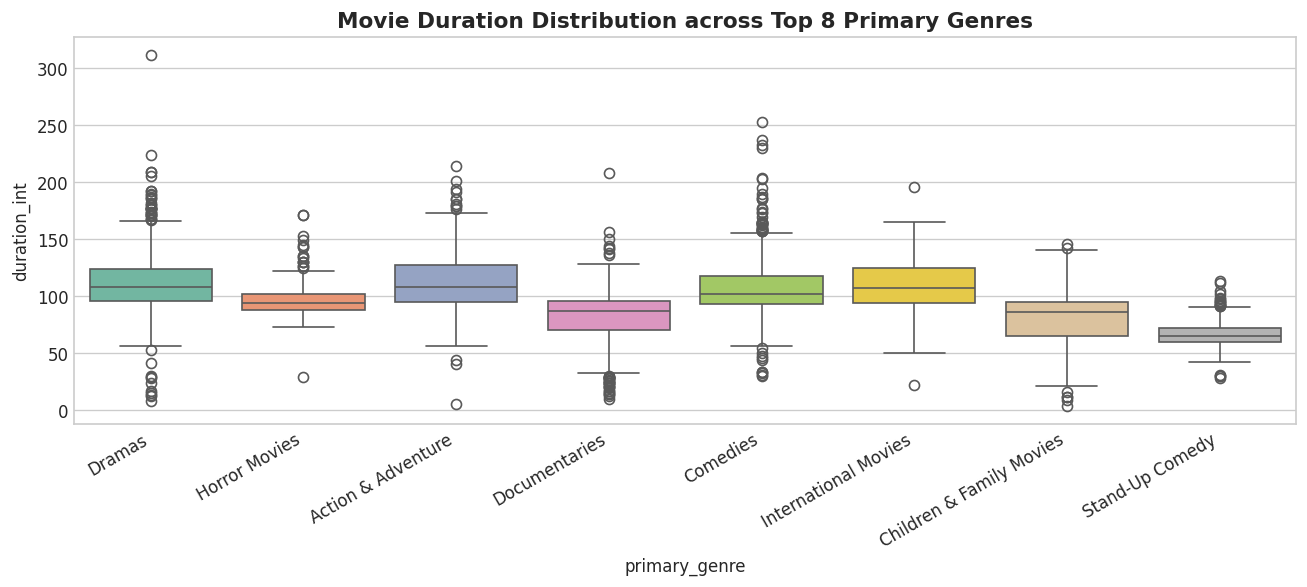

Chi-Square Test (Type vs Target Audience): Chi2 = 99.7083, p-value = 1.7957e-21
ANOVA Test (Duration across Top 5 Genres): F-stat = 359.1099, p-value = 3.9173e-268


In [12]:
movies_df = df_proc[df_proc['type'] == 'Movie'].copy()
top_8_movie_genres = movies_df['primary_genre'].value_counts().head(8).index
movies_top_genres = movies_df[movies_df['primary_genre'].isin(top_8_movie_genres)]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(x='primary_genre', y='duration_int', data=movies_top_genres, hue='primary_genre', palette='Set2', legend=False, ax=ax)
ax.set_title('Movie Duration Distribution across Top 8 Primary Genres', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Chi-Square Test
ct_aud = pd.crosstab(df_proc['type'], df_proc['target_audience'])
chi2, p_val, dof, _ = stats.chi2_contingency(ct_aud)
print(f"Chi-Square Test (Type vs Target Audience): Chi2 = {chi2:.4f}, p-value = {p_val:.4e}")

# ANOVA Test
top_5_m_genres = movies_df['primary_genre'].value_counts().head(5).index
genre_groups = [movies_df[movies_df['primary_genre'] == g]['duration_int'].dropna() for g in top_5_m_genres]
f_stat, p_val_anova = stats.f_oneway(*genre_groups)
print(f"ANOVA Test (Duration across Top 5 Genres): F-stat = {f_stat:.4f}, p-value = {p_val_anova:.4e}")

### 16. Data Transformations and Aggregations
Summary of transformations documented during EDA:
1. Datetime parsing (`date_added` → `year_added`, `month_name_added`).
2. Multi-valued field unnesting (`country` & `listed_in` string splitting and exploding).
3. Numerical duration extraction (`duration` string parsing into `duration_int` and `duration_unit`).
4. Content age lag computation (`year_added` - `release_year`).
5. Audience target grouping (`rating` map into `Kids`, `Teens`, `Adults`, `Unrated`).

### 17. Visualizations Overview
All 12 high-resolution visualizations created during EDA are stored in `../visualizations/week2/`:
- `w2_01_content_type_distribution.png`
- `w2_02_release_year_trends.png`
- `w2_03_top_contributing_countries.png`
- `w2_04_top_listed_genres.png`
- `w2_05_content_ratings_by_type.png`
- `w2_06_movie_duration_histogram.png`
- `w2_07_tv_show_seasons_distribution.png`
- `w2_08_genre_content_type_heatmap.png`
- `w2_09_monthly_content_additions.png`
- `w2_10_content_age_lag_distribution.png`
- `w2_11_movie_duration_by_genre_boxplot.png`
- `w2_12_country_type_breakdown.png`

### 18. Interpretation of Findings
1. **Catalog Composition:** Movies dominate the catalog (69.05%), but TV Show additions grew significantly after 2016.
2. **Geographic Distribution:** The US is the leading provider (3,297 titles), followed by India (990 titles, predominantly movies) and the UK (723 titles).
3. **Genre Dominance:** International Movies, Dramas, and Comedies represent the top content categories.
4. **Rating Insights:** Mature content (`TV-MA` and `R`) constitutes over 46% of all content, reflecting an adult-oriented licensing strategy.
5. **Duration Metrics:** Movie durations follow a normal distribution centered at 99.3 minutes (median 98 minutes), whereas 66.7% of TV Shows feature only 1 season.

### 19. Limitations
1. **Right-Censoring:** Data collection cuts off in early 2021.
2. **Missing Granular Viewing Data:** Lacks viewership figures, watch time, ratings, or subscriber metrics.
3. **Imputed Fields:** Missing dates and countries filled during Week 1 introduce minor categorical noise.

### 20. Conclusion
This EDA notebook successfully establishes the descriptive and visual foundations of the Netflix Movies and TV Shows dataset. The findings reveal strategic shifts towards original series, global acquisition expansion, and clear structural differences between feature films and television series.